In [1]:
import pandas as pd

data = pd.read_csv('/content/ecommerce_logistics_delivery_cleaned.csv')

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset shape: (15000, 36)

Columns:
['Order_ID', 'Order_Date', 'Product_Category', 'Customer_Region', 'Warehouse_Region', 'Shipping_Method', 'Delivery_Partner', 'Payment_Method', 'Order_Value', 'Order_Quantity', 'Package_Weight_KG', 'Package_Volume_CM3', 'Distance_KM', 'Warehouse_Processing_Hours', 'Traffic_Delay_Minutes', 'Weather_Delay_Minutes', 'Courier_Rating', 'Courier_Experience_Years', 'Warehouse_Capacity_Utilization', 'Inventory_Availability', 'Weekend_Flag', 'Holiday_Flag', 'Promotion_Flag', 'Estimated_Delivery_Hours', 'Promised_Delivery_Hours', 'Delivery_Delay_Hours', 'On_Time_Delivery_Flag', 'Cancellation_Flag', 'Return_Flag', 'Shipping_Cost', 'Logistics_Cost', 'Customer_Satisfaction_Score', 'Delivery_Status', 'Order_Hour', 'Day_of_Week', 'Month']


In [2]:
print(data['Delivery_Delay_Hours'].describe())

count    15000.000000
mean         0.155503
std          0.160484
min          0.000000
25%          0.000000
50%          0.118350
75%          0.255063
max          1.000000
Name: Delivery_Delay_Hours, dtype: float64


In [3]:
features = [
    'Distance_KM',
    'Warehouse_Processing_Hours',
    'Traffic_Delay_Minutes',
    'Weather_Delay_Minutes',
    'Courier_Rating',
    'Courier_Experience_Years',
    'Warehouse_Capacity_Utilization',
    'Estimated_Delivery_Hours',
    'Promised_Delivery_Hours',
    'Shipping_Cost',
    'Logistics_Cost',
    'Package_Weight_KG',
    'Package_Volume_CM3',
    'Order_Quantity'
]

target = 'Delivery_Delay_Hours'

X = data[features]
y = data[target]

print("Number of features:", len(features))
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 14
Target: Delivery_Delay_Hours
X shape: (15000, 14)
y shape: (15000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 12000
Testing records: 3000


In [5]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 0.048876870728055584
RMSE: 0.0642573213112007
R²: 0.8389633016032518


In [7]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Decision Tree
MAE: 0.007325254845791459
RMSE: 0.012212416421032808
R²: 0.9941832173983194


In [8]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("Random Forest")
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

Random Forest
MAE: 0.00198237297502295
RMSE: 0.008030791656344563
R²: 0.9974846620584125


In [9]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    'RMSE': [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    'R2': [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

model_results.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,0.0489,0.0643,0.8390
1,Decision Tree,0.0073,0.0122,0.9942
2,Random Forest,0.0020,0.0080,0.9975


In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    forest_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross-validation R² scores:", cv_scores)
print("Mean Cross-validation R²:", cv_scores.mean())

Cross-validation R² scores: [0.99726408 0.99426788 0.99825815 0.99792025 0.99616323]
Mean Cross-validation R²: 0.9967747191484062


In [13]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': forest_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                           Feature  Importance
7         Estimated_Delivery_Hours    0.551056
8          Promised_Delivery_Hours    0.194242
10                  Logistics_Cost    0.184400
6   Warehouse_Capacity_Utilization    0.065227
3            Weather_Delay_Minutes    0.000726
5         Courier_Experience_Years    0.000611
9                    Shipping_Cost    0.000598
4                   Courier_Rating    0.000533
12              Package_Volume_CM3    0.000529
11               Package_Weight_KG    0.000527
1       Warehouse_Processing_Hours    0.000493
2            Traffic_Delay_Minutes    0.000473
0                      Distance_KM    0.000377
13                  Order_Quantity    0.000207


In [15]:
import matplotlib.pyplot as plt

In [18]:
y_pred_forest = forest_model.predict(X_test)

print(y_pred_forest[:10])

[6.57375457e-02 1.25041604e-01 4.27795102e-01 3.76801444e-07
 3.76801444e-07 2.51231511e-01 9.29844787e-09 2.87701209e-01
 1.42138418e-01 9.55698500e-03]


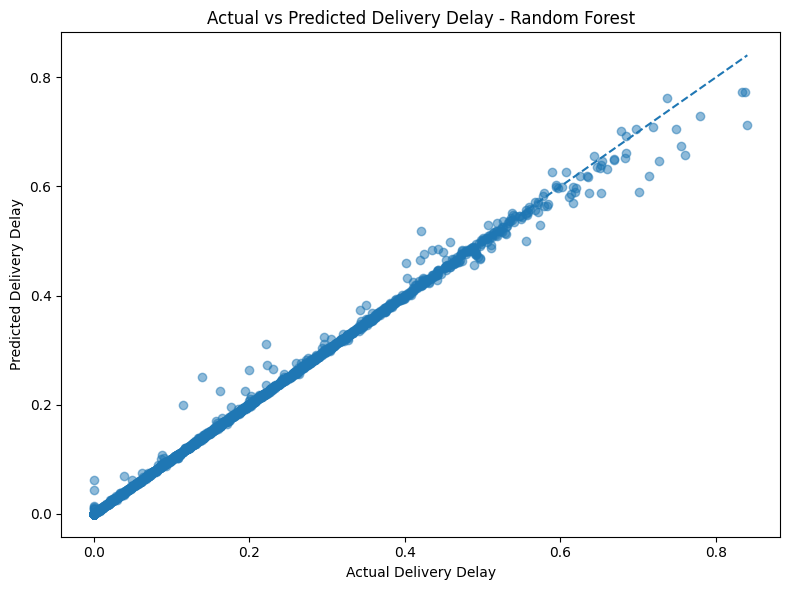

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_forest, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Delivery Delay')
plt.ylabel('Predicted Delivery Delay')
plt.title('Actual vs Predicted Delivery Delay - Random Forest')

plt.tight_layout()
plt.show()

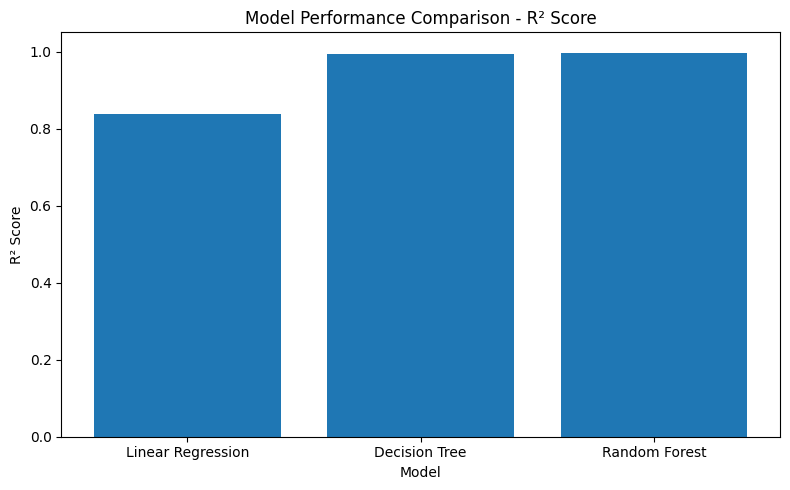

In [20]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    0.8389633016032518,
    0.9941832173983194,
    0.9974846620584125
]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_scores)

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison - R² Score')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

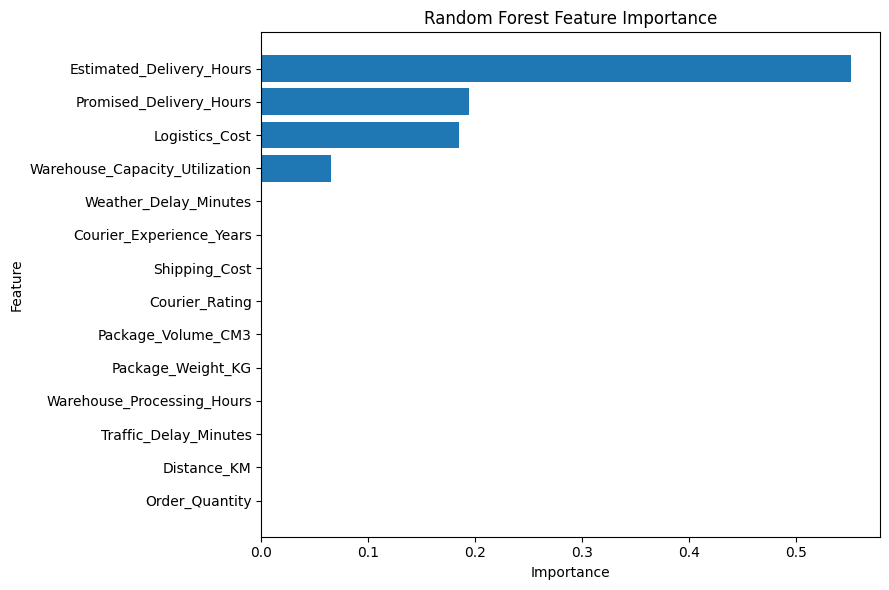

In [21]:
plt.figure(figsize=(9, 6))

importance_plot = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.barh(
    importance_plot['Feature'],
    importance_plot['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig('03_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

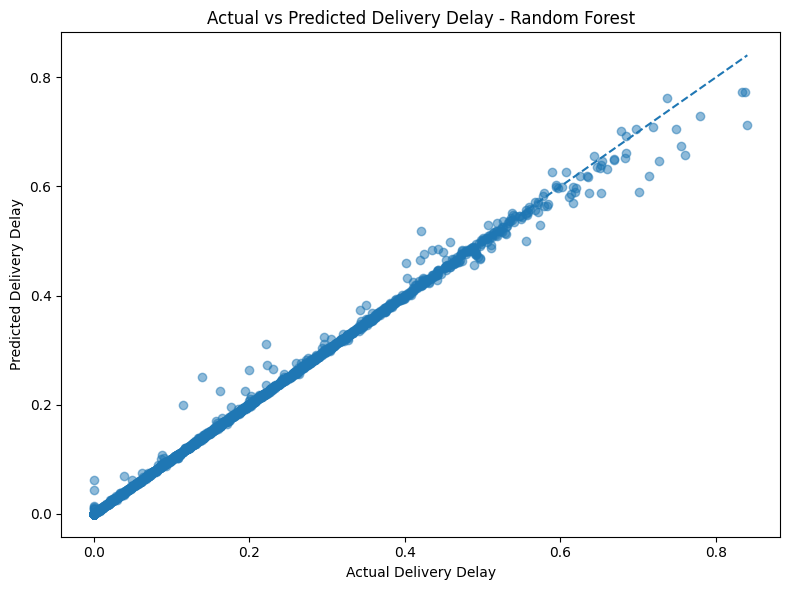

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_forest, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Delivery Delay')
plt.ylabel('Predicted Delivery Delay')
plt.title('Actual vs Predicted Delivery Delay - Random Forest')

plt.tight_layout()

plt.savefig('04_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

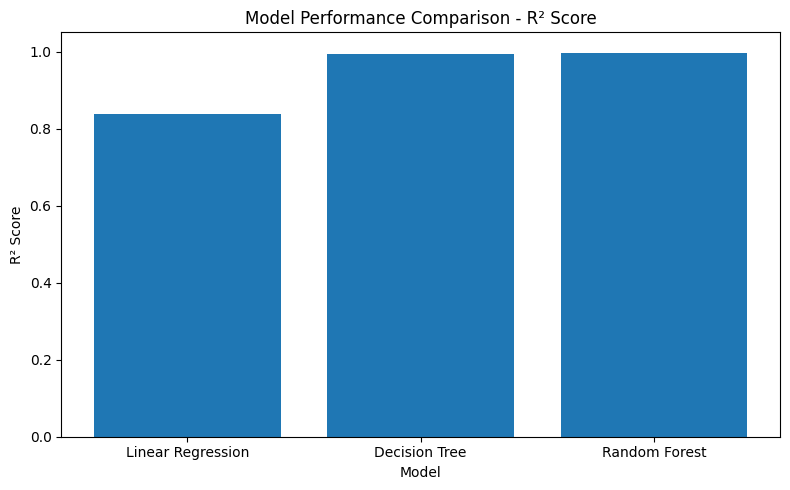

In [23]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    0.8389633016032518,
    0.9941832173983194,
    0.9974846620584125
]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_scores)

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison - R² Score')
plt.ylim(0, 1.05)

plt.tight_layout()

plt.savefig('05_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()